# package_DBR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode

In [2]:
help(SelectPath_RT)

Help on function SelectPath_RT in module package_DBR:

SelectPath_RT(path, time, signal)
    The function "SelectPath_RT" needs to be included in a "for or while loop".

    :path: dictionary input describing a path in time. Example: path = {0: 0, 5: 1, 50: 2, 80: 3, 100: 3}
    :time: time vector.
    :signal: signal vector that is being constructed using the input "path" and the vector "time".

    The function "SelectPath_RT" takes the last element in the vector "time" and, given the input "path", it appends the correct value to the vector "signal".



[False, False, False, False, False, False, False, False, False, False]


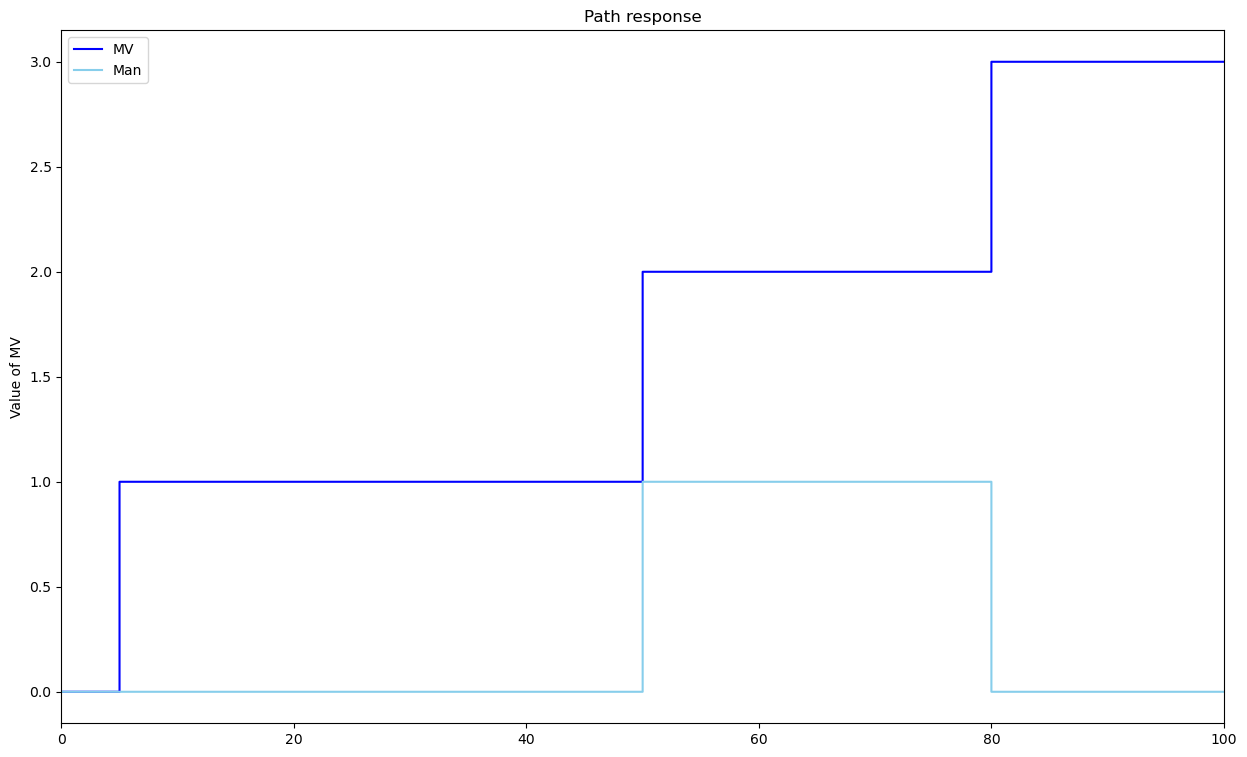

In [3]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV and MVMan
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}
ManPath = {0: False, 5: False, 50: True, 80: False, TSim: False}

t = []
MV = []
Man = []

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    SelectPath_RT(ManPath,t,Man)    
    
plt.figure(figsize = (15,9))

plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,Man,'skyblue',label='Man',where='post')
plt.ylabel('Value of MV')
plt.legend(loc='best')
plt.title('Path response')
plt.xlim([0, TSim])

print(Man[0:10])

# Load data

In [4]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-09h18.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

MV


In [5]:
#graphical method
Tg = 169
Tu = 19
t1 = 68
t2 = 87
Kp = 0.28
a = 0.07
e = 2.71828

Kp_FOPDTBR = Kp
T_FOPDTBR =  Tg
theta_FOPDTBR = Tu

Kp_FOPDTBR2 =  Kp
T_FOPDTBR2 =  5.5*(t2-t1)
theta_FOPDTBR2 = 2.8*t1-1.8*t2

Kp_SOPDTVDG = Kp
T1_SOPDTVDG = Tg*(((3*a*np.e)-1)/(1+ (a*np.e)))
T2_SOPDTVDG = Tg*((1-(a*np.e))/(1+ (a*np.e)))
theta_SOPDTVDG = Tu - (T1_SOPDTVDG*T2_SOPDTVDG)/(T1_SOPDTVDG + (3*T2_SOPDTVDG))

Ts = 1
print(T1_SOPDTVDG, T2_SOPDTVDG)

-60.9337252431706 114.96686262158532


# Parameters optimal FOPDT & SOPDT models

In [6]:
Kp_FOPDTOPT =  0.607917185120446
T_FOPDTOPT =  167.7612785031609
theta_FOPDTOPT = 30.160755248939658

Kp_SOPDTOPT = 0.5989736896344007
T1_SOPDTOPT = 149.6233985843682
T2_SOPDTOPT = 32.50169912582417
theta_SOPDTOPT = 7.000000010762263   

Ts = 1

# Compare step responses (experiment compared with optimal FOPDT & SOPDT)

(0.0, 388.0)

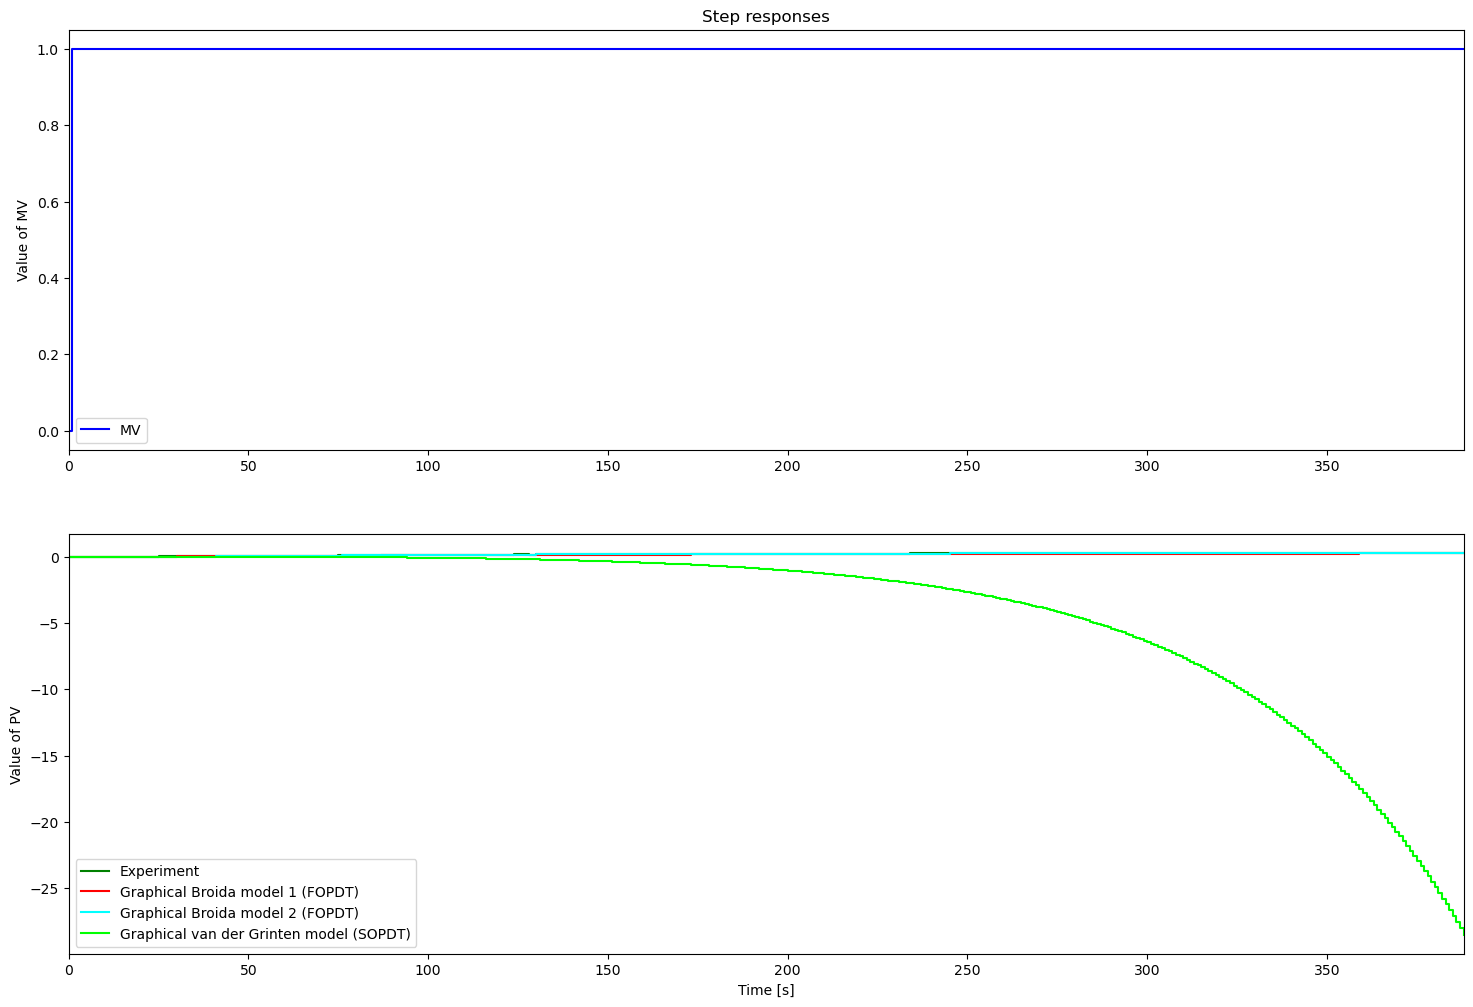

In [7]:
PV_SOPDTVDG = SOPDT(MVm,Kp_SOPDTVDG,T1_SOPDTVDG,T2_SOPDTVDG,theta_SOPDTVDG,Ts)
PV_FOPDTBR = FOPDT(MVm,Kp_FOPDTBR,T_FOPDTBR,theta_FOPDTBR,Ts)
PV_FOPDTBR2 = FOPDT(MVm,Kp_FOPDTBR2,T_FOPDTBR2,theta_FOPDTBR2,Ts)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTBR,'red',label='Graphical Broida model 1 (FOPDT)',where='post')
plt.step(tm,PV_FOPDTBR2,'cyan',label='Graphical Broida model 2 (FOPDT)',where='post')
plt.step(tm,PV_SOPDTVDG,'lime',label='Graphical van der Grinten model (SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Compare Bode diagrams (optimal FOPDT & SOPDT)

Text(0, 0.5, 'Phase [°]')

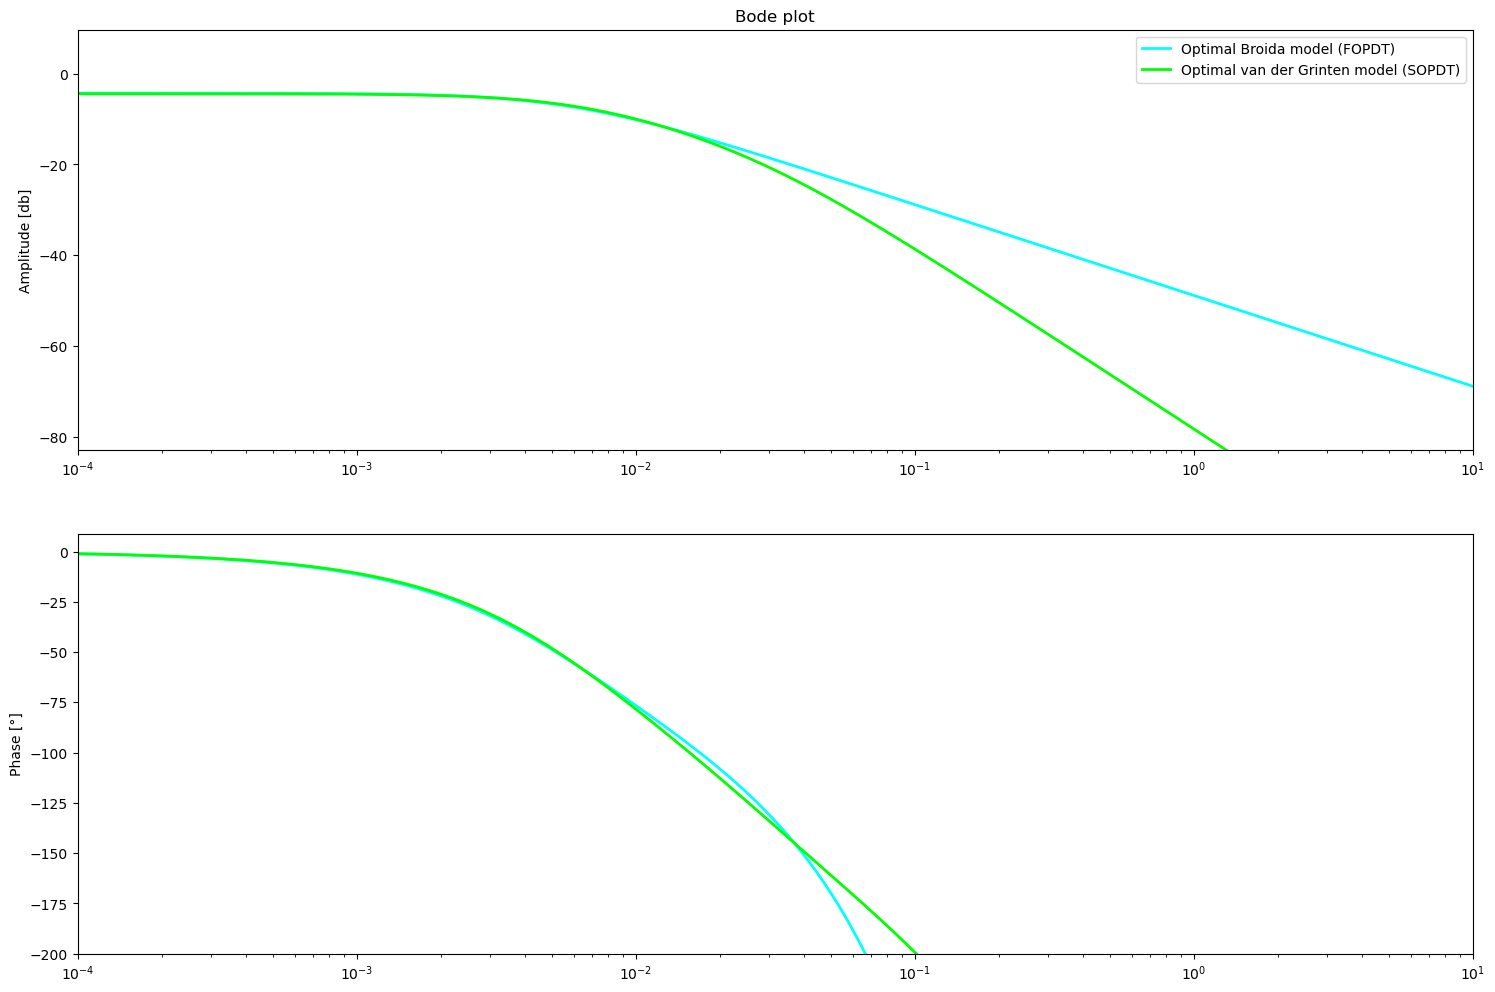

In [8]:
# Frequency response
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

# Frequency response
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')